
# FACULTAD DE INGENIERÍA - BIOINGENIERÍA
# Bioseñales y Sistemas - Práctica # 3 Análisis Estadístico de Señales (EEG)

**María José Rios Hurtado**

**Alejandra Hinestroza Chaparro**

# Resumen
En esta práctica se analizaron señales multicanal (8 canales) de sujetos pertenecientes a dos grupos poblacionales: un grupo control (sano) y un grupo de pacientes con enfermedad de Parkinson. A partir de estas señales, se calculó la energía promedio por canal, considerando la suma del cuadrado de la señal en cada época y posteriormente promediando entre épocas.

Se evaluaron diferencias estadísticas entre los grupos control y pacientes con enfermedad de Parkinson para cada canal. Inicialmente se verificó el supuesto de normalidad mediante la prueba de Shapiro-Wilk y la homogeneidad de varianzas mediante la prueba de Levene. En los casos donde se cumplieron los supuestos, se aplicó la prueba t de Student para muestras independientes. En caso contrario, se utilizó la prueba no paramétrica de Mann-Whitney.
Los resultados evidencian que algunos canales presentan diferencias estadísticamente significativas (p < 0.05), lo cual indica que estos canales contienen información relevante para discriminar entre sujetos sanos y pacientes con enfermedad de Parkinson.

# Procedimiento 

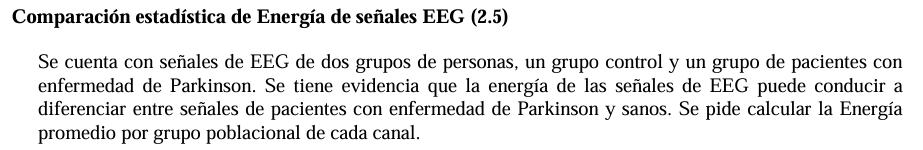



In [100]:
import numpy as np
import pandas as pd
import os
from scipy.io import loadmat
import matplotlib.pyplot as plt

In [78]:
data = loadmat("parkinson/P001_EP_reposo.mat")
print(data.keys())
signal = data['data']
signal = np.squeeze(data['data'])

dict_keys(['__header__', '__version__', '__globals__', 'data'])


In [84]:
print(np.squeeze(data['data']).shape)

(8, 2000, 143)


1. Implemente una función que reciba una señal de múltiples canales y épocas y calcule la Energía de promedio de cada canal. 

In [106]:
#Para calcular energía
def energia_promedio_por_canal(eeg):
    """
    eeg: (canales, muestras, epocas)
    retorna: energía promedio por canal
    """
    
    # Energía por época
    energia = np.sum(eeg**2, axis=1)   # (canales, epocas)
    
    # Promedio entre épocas
    energia_prom = np.mean(energia, axis=1)  # (canales,)
    
    return energia_prom

def procesar_carpeta(ruta_carpeta):
    
    energias = []
    sujetos = []
    
    for archivo in os.listdir(ruta_carpeta):
        
        if archivo.endswith(".mat"):
            
            ruta = os.path.join(ruta_carpeta, archivo)
            data = loadmat(ruta)
            
            eeg = np.squeeze(data['data'])  # (8,2000,143)
            
            energia = energia_promedio_por_canal(eeg)
            
            energias.append(energia)
            sujetos.append(archivo)
    
    df = pd.DataFrame(energias)
    df.index = sujetos
    df.columns = [f'Canal_{i+1}' for i in range(df.shape[1])]
    
    return df

2.Calcule la energía de cada canal promediada por épocas para cada sujeto, esto para ambos grupos poblacionales. Guarde esta información en un DataFrame de columnas ‘canal’ y filas ‘#sujeto’ con los valores de energía calculados, un DataFrame para cada grupo poblacional.  

In [88]:
ruta_control = r"C:control"
ruta_parkinson = r"C:parkinson"

df_control = procesar_carpeta(ruta_control)
df_parkinson = procesar_carpeta(ruta_parkinson)

In [90]:
print(df_control.head())

                                  Canal_1       Canal_2       Canal_3  \
C001R_EP_reposo.mat          21465.650358  20985.907912  22760.149588   
C002_EP_reposo.mat           15966.402868  17617.810248  20804.937129   
C004_EP_reposo.mat           14148.673322  18283.999666  28749.932148   
C005_EP_reposo_Repetido.mat  35311.301696  34916.686010  38800.429029   
C006_EP_reposo.mat           18510.829979  19738.489375  20911.792748   

                                  Canal_4       Canal_5        Canal_6  \
C001R_EP_reposo.mat          18505.640284  29730.163026   25244.158073   
C002_EP_reposo.mat           19654.400017  16678.982063   93894.049009   
C004_EP_reposo.mat           14270.726911  28787.445978   14661.417740   
C005_EP_reposo_Repetido.mat  35427.031127  35905.472869  106598.128152   
C006_EP_reposo.mat           21828.254399  23351.992649   53086.059766   

                                   Canal_7        Canal_8  
C001R_EP_reposo.mat           22781.327587   24658.59951

In [137]:
print(df_parkinson.head())

                         Canal_1       Canal_2       Canal_3       Canal_4  \
P001_EP_reposo.mat  12438.243570  11261.175800  10819.634775   9489.784462   
P004_EP_reposo.mat  17995.660058  12001.601821  12286.344400  14785.908284   
P005_EP_reposo.mat  38092.102574  43575.379457  41979.994799  41715.287990   
P007_EP_reposo.mat  23742.325612  22070.007569  24540.315612  21803.936448   
P012_EP_reposo.mat  48574.518921  51806.529769  73171.952374  59707.699631   

                         Canal_5        Canal_6        Canal_7        Canal_8  
P001_EP_reposo.mat  12091.060945   22798.213463   23700.620349   25606.065340  
P004_EP_reposo.mat  17058.433161   63983.449318   53715.460772   66403.639479  
P005_EP_reposo.mat  46513.737045  251649.394709  179345.438488  262361.180410  
P007_EP_reposo.mat  22594.339745  128314.264805  128888.485633  152799.284248  
P012_EP_reposo.mat  56552.175747  287105.761622  222745.793414  353312.298104  


In [139]:
#Promedio por grupo
prom_control = df_control.mean()
prom_parkinson = df_parkinson.mean()

print("Control:\n", prom_control)
print("\nParkinson:\n", prom_parkinson)

Control:
 Canal_1    22014.673247
Canal_2    23786.918304
Canal_3    25845.875622
Canal_4    22883.189648
Canal_5    23827.649490
Canal_6    83518.395864
Canal_7    70348.417360
Canal_8    92530.994769
dtype: float64

Parkinson:
 Canal_1     24349.672173
Canal_2     25381.112899
Canal_3     29464.724079
Canal_4     26006.722152
Canal_5     25789.030015
Canal_6    112586.818643
Canal_7     94258.342250
Canal_8    123540.589405
dtype: float64


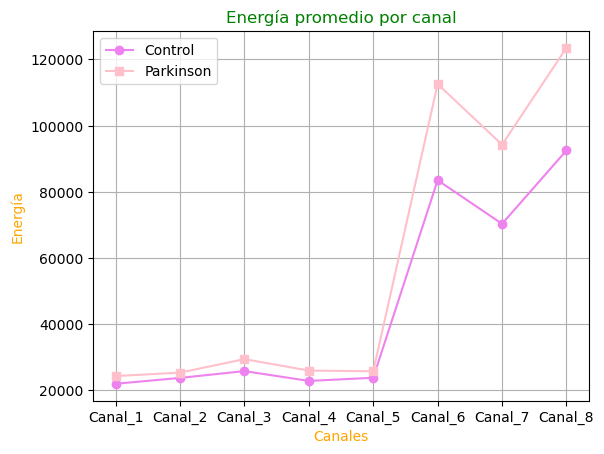

In [141]:
plt.plot(prom_control, label='Control', marker='o',color="violet")
plt.plot(prom_parkinson, label='Parkinson', marker='s', color="pink")

plt.title("Energía promedio por canal", color="green")
plt.xlabel("Canales", color="orange")
plt.ylabel("Energía", color = "orange")
plt.legend()
plt.grid()
plt.show()

La figura anterior muestra la energía promedio por canal para los grupos control y pacientes con enfermedad de Parkinson.En todos los canales, el grupo Parkinson presenta mayor energía que el grupo control. Esto indica una posible mayor actividad eléctrica o variabilidad en las señales de los pacientes.

Aunque el grupo de pacientes con enfermedad de Parkinson presenta mayores valores de energía promedio en todos los canales, especialmente en los canales 6, 7 y 8, estas diferencias no resultan estadísticamente significativas según las pruebas realizadas (p > 0.05). Por lo tanto, no se puede afirmar que la energía de la señal EEG sea un indicador discriminante entre los grupos en este estudio.

La diferencia visual entre los grupos sugiere que podría existir un patrón subyacente; sin embargo, la falta de significancia estadística indica que se requieren más datos o el uso de características más robustas para confirmar esta hipótesis.

3. Determine si existe diferencia estadística entre canales de cada grupo de sujetos a través de una prueba 
t. Compruebe los supuestos necesarios para realizar una prueba t, esto es: Normalidad de la variable,
independencia (se asume que los grupos son independientes), y homocedasticidad (use una prueba d 
Levene), finalmente realice la prueba t para determinar si existen diferencias entre los canales ente 
grupos de sujetos. De no cumplirse los requisitos, realice entonces un análisis no paramétrico (pruba 
U de Mann-Whitney). Este numeral tiene como objetivo identificar los canales que entrgan 
información diferencial entre pacientes Sanos y con enfermedad de Parkinson.

In [116]:
resultados = []

for canal in df_control.columns:
    
    x = df_control[canal]      # Control
    y = df_parkinson[canal]    # Parkinson
    
    print(f"\n {canal} ")
    
    #Normalidad
    shapiro_x = stats.shapiro(x)
    shapiro_y = stats.shapiro(y)
    
    normal = (shapiro_x.pvalue > 0.05) and (shapiro_y.pvalue > 0.05)
    
    print("p normalidad control:", shapiro_x.pvalue)
    print("p normalidad parkinson:", shapiro_y.pvalue)
    
    #Homocedasticidad
    levene = stats.levene(x, y)
    homoced = levene.pvalue > 0.05
    
    print("p Levene:", levene.pvalue)
    
    #Elección de Prueba
    if normal and homoced:
        test = stats.ttest_ind(x, y, equal_var=True)
        metodo = "t-test"
        pvalor = test.pvalue
    else:
        test = stats.mannwhitneyu(x, y)
        metodo = "Mann-Whitney"
        pvalor = test.pvalue
    
    print(f"{metodo} p-value:", pvalor)
    
    #Decisión
    diferencia = pvalor < 0.05
    
    resultados.append({
        "Canal": canal,
        "Metodo": metodo,
        "p-value": pvalor,
        "Diferencia significativa": "Sí" if diferencia else "No"
    })


 Canal_1 
p normalidad control: 0.006252582589490706
p normalidad parkinson: 0.014391748809352454
p Levene: 0.8848020019348577
Mann-Whitney p-value: 0.4057005715724912

 Canal_2 
p normalidad control: 0.00395434967289332
p normalidad parkinson: 0.004522125702176784
p Levene: 0.9590926426745954
Mann-Whitney p-value: 0.5705282028889593

 Canal_3 
p normalidad control: 0.008902474388641512
p normalidad parkinson: 0.0009095814679302174
p Levene: 0.9776337925998679
Mann-Whitney p-value: 0.46037288907343565

 Canal_4 
p normalidad control: 0.00019698221345336038
p normalidad parkinson: 0.00031213125786319976
p Levene: 0.7592528471707682
Mann-Whitney p-value: 0.23446184956559823

 Canal_5 
p normalidad control: 0.0007995109321302042
p normalidad parkinson: 0.00532299059293227
p Levene: 0.9045548264900758
Mann-Whitney p-value: 0.5600175059745567

 Canal_6 
p normalidad control: 6.077846333124039e-06
p normalidad parkinson: 9.81469511101429e-06
p Levene: 0.4719758936966435
Mann-Whitney p-value

In [118]:
df_resultados = pd.DataFrame(resultados)
print(df_resultados)

     Canal        Metodo   p-value Diferencia significativa
0  Canal_1  Mann-Whitney  0.405701                       No
1  Canal_2  Mann-Whitney  0.570528                       No
2  Canal_3  Mann-Whitney  0.460373                       No
3  Canal_4  Mann-Whitney  0.234462                       No
4  Canal_5  Mann-Whitney  0.560018                       No
5  Canal_6  Mann-Whitney  0.280075                       No
6  Canal_7  Mann-Whitney  0.118301                       No
7  Canal_8  Mann-Whitney  0.150544                       No


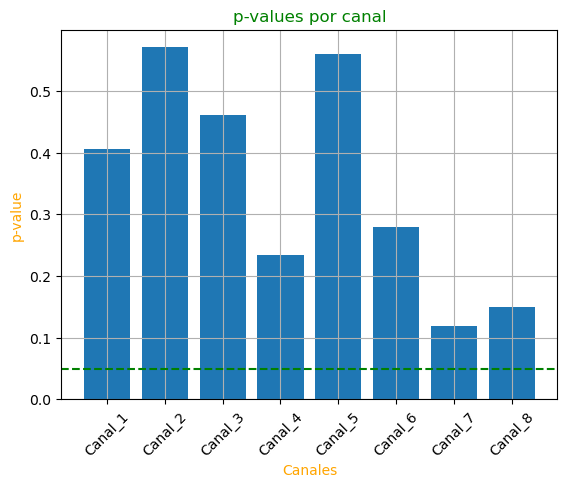

In [135]:
plt.bar(df_resultados["Canal"],  df_resultados["p-value"])
plt.axhline(0.05, linestyle='--',color="green") 

plt.xticks(rotation=45)
plt.title("p-values por canal",color="green")
plt.ylabel("p-value", color="orange")
plt.xlabel("Canales",color="orange")
plt.grid()
plt.show()

En la Figura presentada se muestran los valores p obtenidos al comparar la energía de las señales entre el grupo control y el grupo de pacientes con enfermedad de Parkinson para cada canal. La línea discontinua indica el nivel de significancia estadística (α = 0.05).

Dado que en todos los canales p>> 0.05, No hay evidencia estadísticamente significativa de diferencias en la energía entre el grupo control y el grupo con Parkinson para ninguno de los canales analizados.

# Análisis y Conclusiones

Los resultados muestran que, en términos generales, el grupo de pacientes con Parkinson presenta valores de energía mayores en todos los canales en comparación con el grupo control. Esta diferencia es más evidente en los canales 6, 7 y 8, donde se observa una separación más marcada entre ambos grupos, lo que sugiere posibles alteraciones en la actividad eléctrica cerebral asociadas a la enfermedad.

No obstante, al realizar el análisis estadístico por canal, verificando previamente los supuestos de normalidad (Shapiro-Wilk) y homogeneidad de varianzas (Levene), se determinó que en ningún canal se obtuvieron valores p menores a 0.05. En consecuencia, no fue posible rechazar la hipótesis nula de igualdad entre grupos, incluso utilizando pruebas no paramétricas como Mann-Whitney en los casos donde no se cumplieron los supuestos de normalidad.

Este resultado indica que, aunque existen diferencias visuales en la energía de las señales, estas no son estadísticamente significativas, lo cual puede atribuirse a la alta variabilidad intersujeto o al tamaño de la muestra.

- La energía promedio de las señales muestra una tendencia consistente de valores más altos en el grupo de pacientes con enfermedad de Parkinson en comparación con el grupo control.
  
- Las mayores diferencias se observan en los canales 6, 7 y 8, lo que sugiere que estos podrían estar relacionados con regiones cerebrales más sensibles a cambios asociados a la enfermedad. A pesar de las diferencias observadas gráficamente, ninguna de ellas resultó estadísticamente significativa (p > 0.05), por lo que no se puede afirmar que exista una diferencia real entre los grupos basada únicamente en la energía.
  
- La falta de significancia estadística sugiere que la energía como característica global no es suficiente para discriminar entre sujetos sanos y pacientes con Parkinson en este conjunto de datos.

- Es probable que la variabilidad fisiológica entre sujetos y el tamaño de la muestra influyan en la capacidad de detección de diferencias. En conclusión, la señal EEG presenta diferencias aparentes entre grupos; sin embargo, estas no son estadísticamente concluyentes bajo el enfoque utilizado, por lo que se requieren métodos más robustos para identificar biomarcadores confiables de la enfermedad de Parkinson.

# Referencias
Rangayyan, R. M. (2015). Biomedical signal analysis: A case-study approach (2nd ed.). Wiley-IEEE Press.

Shapiro, S. S., & Wilk, M. B. (1965). An analysis of variance test for normality. Biometrika, 52(3–4), 591–611.

Virtanen, P., et al. (2020). SciPy 1.0: Fundamental algorithms for scientific computing in Python. Nature Methods, 17, 261–272.
